In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
from scipy.optimize import curve_fit
from scipy.integrate import quad

from astropy.constants import c 
from astropy import units as u
 
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

c_kms = c.to('km/s').value
print(f"Speed of light: {c_kms:.2f} km/s")

Speed of light: 299792.46 km/s


In [9]:
file_path = "Pantheon+SH0ES.dat"  
with open(file_path, "r") as f:
    for _ in range(10):
        print(f.readline())

CID IDSURVEY zHD zHDERR zCMB zCMBERR zHEL zHELERR m_b_corr m_b_corr_err_DIAG MU_SH0ES MU_SH0ES_ERR_DIAG CEPH_DIST IS_CALIBRATOR USED_IN_SH0ES_HF c cERR x1 x1ERR mB mBERR x0 x0ERR COV_x1_c COV_x1_x0 COV_c_x0 RA DEC HOST_RA HOST_DEC HOST_ANGSEP VPEC VPECERR MWEBV HOST_LOGMASS HOST_LOGMASS_ERR PKMJD PKMJDERR NDOF FITCHI2 FITPROB m_b_corr_err_RAW m_b_corr_err_VPEC biasCor_m_b biasCorErr_m_b biasCor_m_b_COVSCALE biasCor_m_b_COVADD

2011fe 51 0.00122 0.00084 0.00122 2e-05 0.00082 2e-05 9.74571 1.51621 28.9987 1.51645 29.177 1 0 -0.1076 0.04008 -0.548188 0.13373 9.58436 0.0327221 2.63181 0.0793177 0.00011378 -0.00052525 -0.00272765 210.774 54.2737 -999 -999 -9 0 250 0.00758935 10.677 -9 55815 0.1071 36 26.8859 0.86447 0.0991 1.496 0.0381 0.005 1 0.003

2011fe 56 0.00122 0.00084 0.00122 2e-05 0.00082 2e-05 9.80286 1.51723 29.0559 1.51747 29.177 1 0 -0.032895 0.038463 -0.380481 0.0861 9.78448 0.0352442 2.1888 0.0710511 -0.000443845 -0.00150198 -0.00220084 210.774 54.2737 -999 -999 -9 0 250 0.00

In [10]:


df_full = pd.read_csv(file_path, delim_whitespace=True)

# Display the column names
print("🔍 Column names in the dataset:")
print(df_full.columns.tolist())

# Preview the first 5 rows
df_full.head()


🔍 Column names in the dataset:
['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL', 'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF', 'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c', 'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC', 'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS', 'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB', 'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b', 'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD']


C:\Users\lalit\AppData\Local\Temp\ipykernel_19432\2553095658.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_full = pd.read_csv(file_path, delim_whitespace=True)


,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,0.1071,36,26.8859,0.864470,0.0991,1.4960,0.0381,0.005,1.0,0.003
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,0.0579,101,88.3064,0.812220,0.0971,1.4960,-0.0252,0.003,1.0,0.004
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,0.0278,165,233.5000,0.000358,0.0399,0.7134,0.0545,0.019,1.0,0.036
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,0.0667,55,100.1220,0.000193,0.0931,0.7134,0.0622,0.028,1.0,0.040
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,11.52270,0.880798,...,0.0522,146,109.8390,0.988740,0.0567,0.6110,0.0650,0.009,1.0,0.006


In [11]:
df = df_full[['zHD', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG']].copy()
df.columns = ['z', 'mu', 'mu_err']

# Drop rows with any missing values
df = df.dropna()

# Filter out extremely low redshifts (below 0.005) to reduce peculiar velocity effects
df = df[df['z'] > 0.005]

# Sort by redshift for better plotting
df = df.sort_values('z')

# Convert to NumPy arrays for fitting
z = df['z'].values
mu = df['mu'].values
mu_err = df['mu_err'].values

# Preview cleaned dataset
print(df.head())


          z       mu    mu_err
29  0.00538  31.6512  0.514401
30  0.00548  31.7282  0.501431
31  0.00570  31.9117  0.469628
32  0.00570  31.8985  0.483668
33  0.00571  31.6799  0.375913


C:\Users\lalit\AppData\Local\Temp\ipykernel_19432\3153648994.py:25: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lalit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


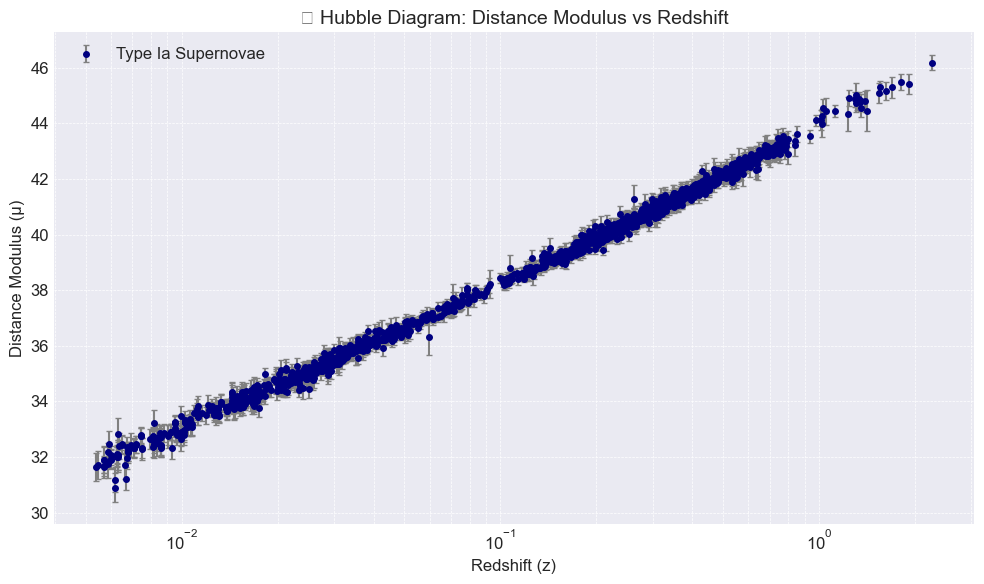

In [12]:
import matplotlib.pyplot as plt

# Plotting the Hubble Diagram
plt.figure(figsize=(10, 6))

plt.errorbar(
    df['z'], df['mu'], yerr=df['mu_err'], fmt='o',
    markersize=4, ecolor='gray', capsize=2,
    color='navy', label='Type Ia Supernovae'
)

# Use logarithmic scale for redshift
plt.xscale('log')

# Labels and title
plt.xlabel('Redshift (z)', fontsize=12)
plt.ylabel('Distance Modulus (μ)', fontsize=12)
plt.title('📈 Hubble Diagram: Distance Modulus vs Redshift', fontsize=14)

# Grid and legend
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()

# Layout adjustment
plt.tight_layout()
plt.show()


In [13]:
import numpy as np
from scipy.integrate import quad

# Speed of light in km/s
c = 3e5

# 1. E(z) function for flat ΛCDM
def E(z, Omega_m):
    return np.sqrt(Omega_m * (1 + z)**3 + (1 - Omega_m))  # assumes flat universe, so ΩΛ = 1 - Ωm

# 2. Luminosity distance in Mpc
def luminosity_distance(z, H0, Omega_m):
    integral, _ = quad(lambda z_prime: 1.0 / E(z_prime, Omega_m), 0, z)
    d_L = (c / H0) * (1 + z) * integral
    return d_L  # in Mpc

# 3. Distance modulus from luminosity distance
def mu_theory(z, H0, Omega_m):
    if np.isscalar(z):
        d_L = luminosity_distance(z, H0, Omega_m)
    else:
        d_L = np.array([luminosity_distance(zi, H0, Omega_m) for zi in z])
    mu = 5 * np.log10(d_L * 1e6) - 5  # convert Mpc to parsecs
    return mu


In [14]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.integrate import quad

# Constants
c_km_s = 3e5  # speed of light in km/s

# Luminosity distance in flat ΛCDM
def luminosity_distance(z, H0, Omega_m):
    def E(z_):
        return 1.0 / np.sqrt(Omega_m * (1 + z_)**3 + (1 - Omega_m))
    
    # Handle scalar or array input
    z = np.atleast_1d(z)
    integral = np.array([quad(E, 0, zi)[0] for zi in z])
    d_l = (c_km_s * (1 + z) / H0) * integral  # in Mpc
    return d_l

# Theoretical distance modulus
def mu_theory(z, H0, Omega_m):
    d_l = luminosity_distance(z, H0, Omega_m)
    return 5 * np.log10(d_l) + 25

# Initial guess for [H0, Omega_m]
p0 = [70, 0.3]

# Fit the model using curve_fit
popt, pcov = curve_fit(mu_theory, z, mu, sigma=mu_err, p0=p0, absolute_sigma=True)

# Extract fitted values and uncertainties
H0_fit, Omega_m_fit = popt
H0_err, Omega_m_err = np.sqrt(np.diag(pcov))

# Print results
print(f"Fitted H₀ = {H0_fit:.2f} ± {H0_err:.2f} km/s/Mpc")
print(f"Fitted Ωₘ = {Omega_m_fit:.3f} ± {Omega_m_err:.3f}")


Fitted H₀ = 73.06 ± 0.26 km/s/Mpc
Fitted Ωₘ = 0.349 ± 0.019


In [15]:
from scipy.integrate import quad
from astropy import units as u
import numpy as np

def age_of_universe(H0, Omega_m):
    """
    Computes the age of the universe in Gyr for a flat ΛCDM cosmology.

    Parameters:
    H0 : float — Hubble constant in km/s/Mpc
    Omega_m : float — Matter density parameter

    Returns:
    Age of universe in gigayears (Gyr)
    """
    # Convert H0 to 1/second
    H0_SI = H0 * (u.km / u.s / u.Mpc).to(1 / u.s)

    # Define H(z)
    def H_z(z):
        return H0_SI * np.sqrt(Omega_m * (1 + z)**3 + (1 - Omega_m))

    # Define integrand
    def integrand(z):
        return 1.0 / ((1 + z) * H_z(z))

    # Integrate from z = 0 to z = 1000
    integral, _ = quad(integrand, 0, 1000)

    # Convert result to seconds, then Gyr
    age_sec = integral * u.s
    age_gyr = age_sec.to(u.Gyr).value

    return age_gyr

# Example usage using fitted values
t0 = age_of_universe(H0_fit, Omega_m_fit)
print(f"Estimated age of Universe: {t0:.2f} Gyr")


Estimated age of Universe: 12.36 Gyr


In [16]:
# Compute theoretical distance modulus using best-fit parameters
mu_model = mu_theory(z, H0_fit, Omega_m_fit)

# Compute residuals: observed - model
residuals = mu - mu_model

# Preview a few residuals
for i in range(5):
    print(f"z = {z[i]:.4f}, μ_obs = {mu[i]:.2f}, μ_model = {mu_model[i]:.2f}, residual = {residuals[i]:.2f}")


z = 0.0054, μ_obs = 31.65, μ_model = 31.73, residual = -0.08
z = 0.0055, μ_obs = 31.73, μ_model = 31.77, residual = -0.04
z = 0.0057, μ_obs = 31.91, μ_model = 31.86, residual = 0.06
z = 0.0057, μ_obs = 31.90, μ_model = 31.86, residual = 0.04
z = 0.0057, μ_obs = 31.68, μ_model = 31.86, residual = -0.18


C:\Users\lalit\AppData\Local\Temp\ipykernel_19432\1852997877.py:16: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lalit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


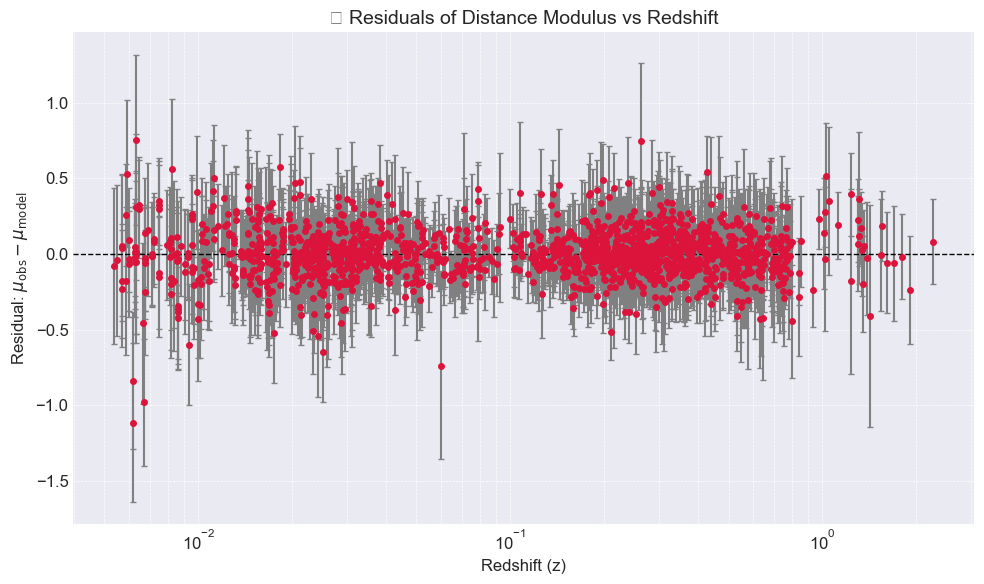

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.errorbar(
    z, residuals, yerr=mu_err, fmt='o',
    color='crimson', ecolor='gray', capsize=2, markersize=4
)

plt.axhline(0, linestyle='--', color='black', linewidth=1)
plt.xscale('log')
plt.xlabel('Redshift (z)', fontsize=12)
plt.ylabel(r'Residual: $\mu_{\mathrm{obs}} - \mu_{\mathrm{model}}$', fontsize=12)
plt.title('📊 Residuals of Distance Modulus vs Redshift', fontsize=14)
plt.grid(True, which='both', ls='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [18]:
from scipy.optimize import curve_fit

# Define a wrapper function with Omega_m fixed at 0.3
def mu_fixed_Om(z, H0):
    return mu_theory(z, H0, Omega_m=0.3)

# Initial guess for H0
H0_guess = 70

# Fit the model (only H0 is free, Omega_m is fixed inside)
popt_fixed, pcov_fixed = curve_fit(
    mu_fixed_Om, z, mu, sigma=mu_err, p0=[H0_guess], absolute_sigma=True
)

# Extract fitted value and uncertainty
H0_fixed = popt_fixed[0]
H0_fixed_err = np.sqrt(pcov_fixed[0][0])

# Print result
print(f"Fitted H₀ (fixed Ωₘ = 0.3): {H0_fixed:.2f} ± {H0_fixed_err:.2f} km/s/Mpc")


Fitted H₀ (fixed Ωₘ = 0.3): 73.60 ± 0.17 km/s/Mpc


In [19]:
from scipy.optimize import curve_fit

# Define the split point
z_split = 0.1

# Create masks
low_z_mask = z < z_split
high_z_mask = z >= z_split

# Split the data
z_low, mu_low, mu_err_low = z[low_z_mask], mu[low_z_mask], mu_err[low_z_mask]
z_high, mu_high, mu_err_high = z[high_z_mask], mu[high_z_mask], mu_err[high_z_mask]

# Define model with fixed Omega_m = 0.3
def mu_fixed_Om(z, H0):
    return mu_theory(z, H0, Omega_m=0.3)

# Fit for low-z
popt_low, cov_low = curve_fit(mu_fixed_Om, z_low, mu_low, sigma=mu_err_low, p0=[70], absolute_sigma=True)
H0_low = popt_low[0]

# Fit for high-z
popt_high, cov_high = curve_fit(mu_fixed_Om, z_high, mu_high, sigma=mu_err_high, p0=[70], absolute_sigma=True)
H0_high = popt_high[0]

# Print the results
print(f"Low-z  (z < {z_split}):   H₀ = {H0_low:.2f} km/s/Mpc")
print(f"High-z (z ≥ {z_split}):   H₀ = {H0_high:.2f} km/s/Mpc")


Low-z  (z < 0.1):   H₀ = 73.10 km/s/Mpc
High-z (z ≥ 0.1):   H₀ = 73.90 km/s/Mpc
